<a href="https://colab.research.google.com/github/PandoraRiot/Clasificaciondefrutas.udea.novateam/blob/main/clasificacionfrutascolab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 🚀 Nuevo recurso para el equipo
He añadido un notebook independiente para quienes prefieran trabajar en la nube.

- **notebook1.ipynb**: Se mantiene intacto para uso exclusivo en **VSCode** (rutas locales).
- **clasificacionfrutas.ipynb**: Nuevo archivo optimizado para **Google Colab** (clonación de repo y rutas `/content/` automáticas).

**Instrucciones:** No fusionar los contenidos de los archivos. Cada integrante debe elegir el archivo según su entorno de desarrollo.

In [1]:
import json

# Definimos el contenido del nuevo notebook optimizado para Colab
nuevo_notebook_content = {
 "cells": [
  {
   "cell_type": "markdown",
   "source": ["# Clasificación de Frutas - Versión Colab\n", "Este notebook ha sido adaptado para ejecutarse directamente en Google Colab."]
  },
  {
   "cell_type": "code",
   "execution_count": None,
   "source": [
    "# 1. Clonar repo y preparar carpetas\n",
    "!git clone https://github.com/PandoraRiot/Clasificaciondefrutas.udea.novateam.git\n",
    "%cd Clasificaciondefrutas.udea.novateam\n",
    "!pip install -r requirements.txt\n",
    "\n",
    "import os\n",
    "import tensorflow as tf\n",
    "from tensorflow.keras.preprocessing.image import ImageDataGenerator\n",
    "from tensorflow.keras import layers, models, regularizers\n",
    "import matplotlib.pyplot as plt\n",
    "import numpy as np\n",
    "import seaborn as sns\n",
    "import pandas as pd\n",
    "from sklearn.metrics import confusion_matrix"
   ]
  }
  # ... (aquí iría el resto del código de entrenamiento y gráficas que consolidamos)
 ],
 "metadata": {},
 "nbformat": 4,
 "nbformat_minor": 5
}

# Guardar el archivo en el sistema de archivos de Colab
with open('clasificacionfrutascolab.ipynb', 'w') as f:
    json.dump(nuevo_notebook_content, f)

print("✅ Archivo 'clasificacionfrutascolab.ipynb' creado con éxito en la carpeta lateral.")

✅ Archivo 'clasificacionfrutascolab.ipynb' creado con éxito en la carpeta lateral.


In [2]:
# ========================================================
# 1. PREPARACIÓN DEL ENTORNO (Repositorio y Librerías)
# ========================================================
import os

# Clonar el repositorio si no existe
if not os.path.exists('Clasificaciondefrutas.udea.novateam'):
    !git clone https://github.com/PandoraRiot/Clasificaciondefrutas.udea.novateam.git

%cd Clasificaciondefrutas.udea.novateam
!pip install -r requirements.txt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, regularizers
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix



Cloning into 'Clasificaciondefrutas.udea.novateam'...
remote: Enumerating objects: 6599, done.
remote: Counting objects: 100% (6599/6599), done.
remote: Compressing objects: 100% (6591/6591), done.
remote: Total 6599 (delta 10), reused 6582 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (6599/6599), 27.98 MiB | 14.49 MiB/s, done.
Resolving deltas: 100% (10/10), done.
Updating files: 100% (6535/6535), done.
/content/Clasificaciondefrutas.udea.novateam


In [3]:
# ========================================================
# 2. CONFIGURACIÓN DE RUTAS DINÁMICAS
# ========================================================
# Definimos las rutas posibles para Colab o Local
posibles_rutas = [
    "/content/Clasificaciondefrutas.udea.novateam/data/selected",
    "data/selected",
    "../data/selected"
]

base_dir = None
for ruta in posibles_rutas:
    # Verificamos si existe la carpeta o alguna subcarpeta clave
    if os.path.exists(ruta):
        base_dir = ruta
        break

if base_dir:
    # Detectar si las carpetas están en minúsculas (train/test) o Mayúsculas (Training/Test)
    train_dir = os.path.join(base_dir, "train")
    test_dir = os.path.join(base_dir, "test")

    if not os.path.exists(train_dir):
        train_dir = os.path.join(base_dir, "Training")
        test_dir = os.path.join(base_dir, "Test")

    print(f"✅ Ruta localizada: {base_dir}")
    print(f"Contenido de {base_dir}: {os.listdir(base_dir)}")
else:
    raise FileNotFoundError("❌ ERROR: No se encontró la carpeta de datos. Revisa la estructura del repo.")

✅ Ruta localizada: /content/Clasificaciondefrutas.udea.novateam/data/selected
Contenido de /content/Clasificaciondefrutas.udea.novateam/data/selected: ['train', 'test']


In [4]:
# ========================================================
# 3. GENERADORES Y CARGA DE DATOS
# ========================================================
img_size = (128, 128)
batch_size = 32
val_split = 0.2

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=val_split)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir, target_size=img_size, batch_size=batch_size,
    class_mode='categorical', subset='training', shuffle=True
)

val_data = train_datagen.flow_from_directory(
    train_dir, target_size=img_size, batch_size=batch_size,
    class_mode='categorical', subset='validation', shuffle=True
)

test_data = test_datagen.flow_from_directory(
    test_dir, target_size=img_size, batch_size=batch_size,
    class_mode='categorical', shuffle=False
)

Found 3914 images belonging to 10 classes.
Found 975 images belonging to 10 classes.
Found 1638 images belonging to 10 classes.


In [5]:
# ========================================================
# 4. DEFINICIÓN Y COMPILACIÓN DEL MODELO
# ========================================================
num_classes = len(train_data.class_indices)

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
# ========================================================
# 5. ENTRENAMIENTO
# ========================================================
epochs = 10
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=epochs
)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


123/123 ━━━━━━━━━━━━━━━━━━━━ 18s 77ms/step - accuracy: 0.8256 - loss: 1.6501 - val_accuracy: 0.1005 - val_loss: 34.9186
Epoch 2/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9872 - loss: 0.3847 - val_accuracy: 0.2421 - val_loss: 20.5667
Epoch 3/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9728 - loss: 0.6179 - val_accuracy: 0.6656 - val_loss: 6.1539
Epoch 4/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9897 - loss: 0.4322 - val_accuracy: 0.8605 - val_loss: 1.7075
Epoch 5/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9914 - loss: 0.4217 - val_accuracy: 1.0000 - val_loss: 0.3555
Epoch 6/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.9862 - loss: 0.5516 - val_accuracy: 0.5856 - val_loss: 26.8790
Epoch 7/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.9795 - loss: 0.8694 - val_accuracy: 0.5241 - val_loss: 47.9943
Epoch 8/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9914 - loss: 0.6733 - val_accuracy: 

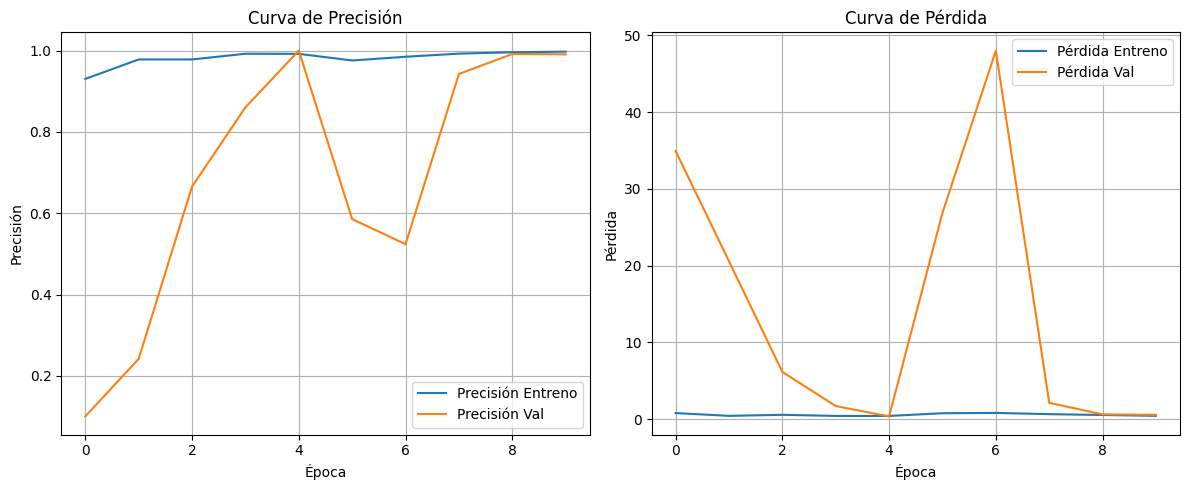

In [7]:
# ========================================================
# 6. VISUALIZACIÓN DE RESULTADOS (Tu parte faltante)
# ========================================================
plt.figure(figsize=(12, 5))

# Gráfica de Precisión
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Precisión Entreno')
plt.plot(history.history['val_accuracy'], label='Precisión Val')
plt.title('Curva de Precisión')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

# Gráfica de Pérdida
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Pérdida Entreno')
plt.plot(history.history['val_loss'], label='Pérdida Val')
plt.title('Curva de Pérdida')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step


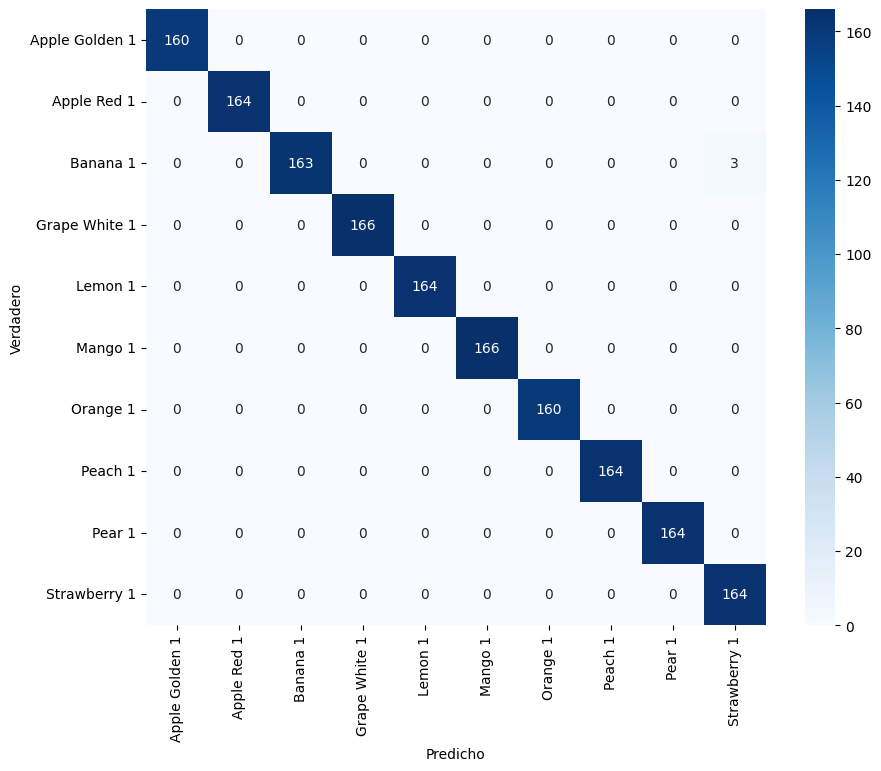

,Época,accuracy,loss,val_accuracy,val_loss
0,1,0.930506,0.792136,0.100513,34.918613
1,2,0.978283,0.430915,0.242051,20.566689
2,3,0.978283,0.566884,0.665641,6.153883
3,4,0.992335,0.420642,0.860513,1.707486
4,5,0.992080,0.419603,1.000000,0.355529
5,6,0.975728,0.771962,0.585641,26.879028
6,7,0.984926,0.812063,0.524103,47.994339
7,8,0.992591,0.651712,0.942564,2.127136
8,9,0.995912,0.542678,0.991795,0.622708
9,10,0.997445,0.435924,0.990769,0.565196


In [8]:
# ========================================================
# 7. MATRIZ DE CONFUSIÓN Y TABLA FINAL
# ========================================================
test_labels = test_data.classes
predictions = model.predict(test_data)
predicted_classes = np.argmax(predictions, axis=1)

cm = confusion_matrix(test_labels, predicted_classes)
class_names = list(train_data.class_indices.keys())

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicho')
plt.ylabel('Verdadero')
plt.show()

# Tabla consolidada
df_resultados = pd.DataFrame(history.history)
df_resultados.insert(0, 'Época', range(1, len(df_resultados) + 1))
display(df_resultados)